##### Must do when training a model

- Must optimise your model to find the optimal parameters -> do this either using an optimization method (gradient descent, standard error, etc..) or brute force (GridSearchCV)

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from imblearn.over_sampling import SMOTE, ADASYN

### Import trainingset

In [2]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_09_variable_trainingset_2.csv')
df = pd.read_csv(x).drop(columns='Unnamed: 0')
df = df.iloc[0::1792, :]

id = df.loc[:, 'condition_id']
X = df.drop(columns=['condition_id', 'condition'])
y = df.loc[:, 'condition']

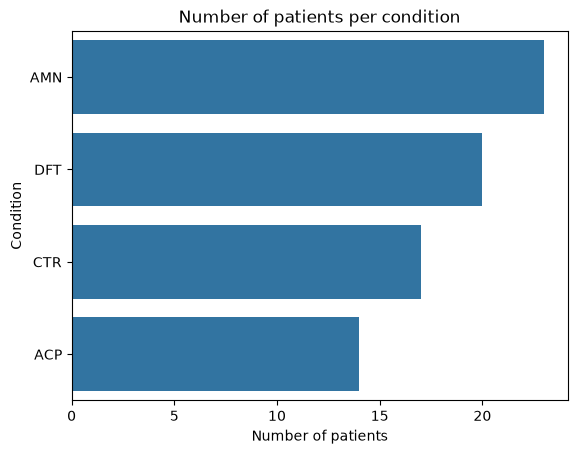

In [ ]:
# (df.condition.value_counts()/6).plot.barh()

ax = sns.barplot(data = df.condition.value_counts()/6, orient='h')
ax.set(xlabel='Number of patients', ylabel='Condition', title='Number of patients per condition')

# plt.savefig('figures/missing_conds.png', dpi=150)

### Rebalancing dataset

In [8]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
# X_resampled, y_resampled = ADASYN(sampling_strategy='minority').fit_resample(X, y)

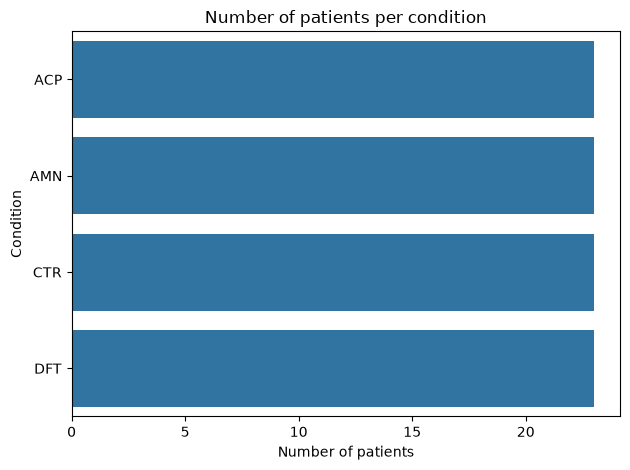

In [9]:
test = pd.concat([X_resampled, y_resampled], axis=1)

ax = sns.barplot(data = test.condition.value_counts()/6, orient='h')
ax.set(xlabel='Number of patients', ylabel='Condition', title='Number of patients per condition')

# plt.savefig('figures/balanced_whole_dataset_barh', dpi=150)

plt.tight_layout()

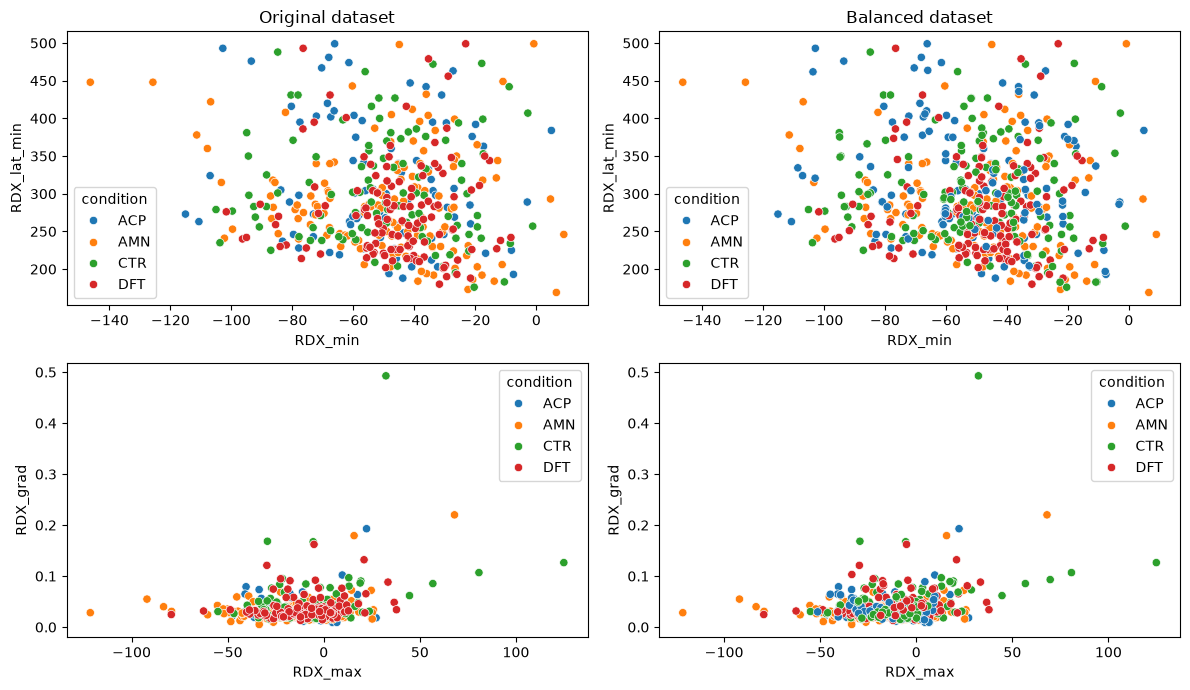

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))


sns.scatterplot(df, x='RDX_min', y='RDX_lat_min', ax=ax[0][0], hue='condition')
sns.scatterplot(df, x='RDX_max', y='RDX_grad', ax=ax[1][0], hue='condition')

sns.scatterplot(test, x='RDX_min', y='RDX_lat_min', ax=ax[0][1], hue='condition')
sns.scatterplot(test, x='RDX_max', y='RDX_grad', ax=ax[1][1], hue='condition')

ax[0][0].set_title('Original dataset')
ax[0][1].set_title('Balanced dataset')

plt.tight_layout()

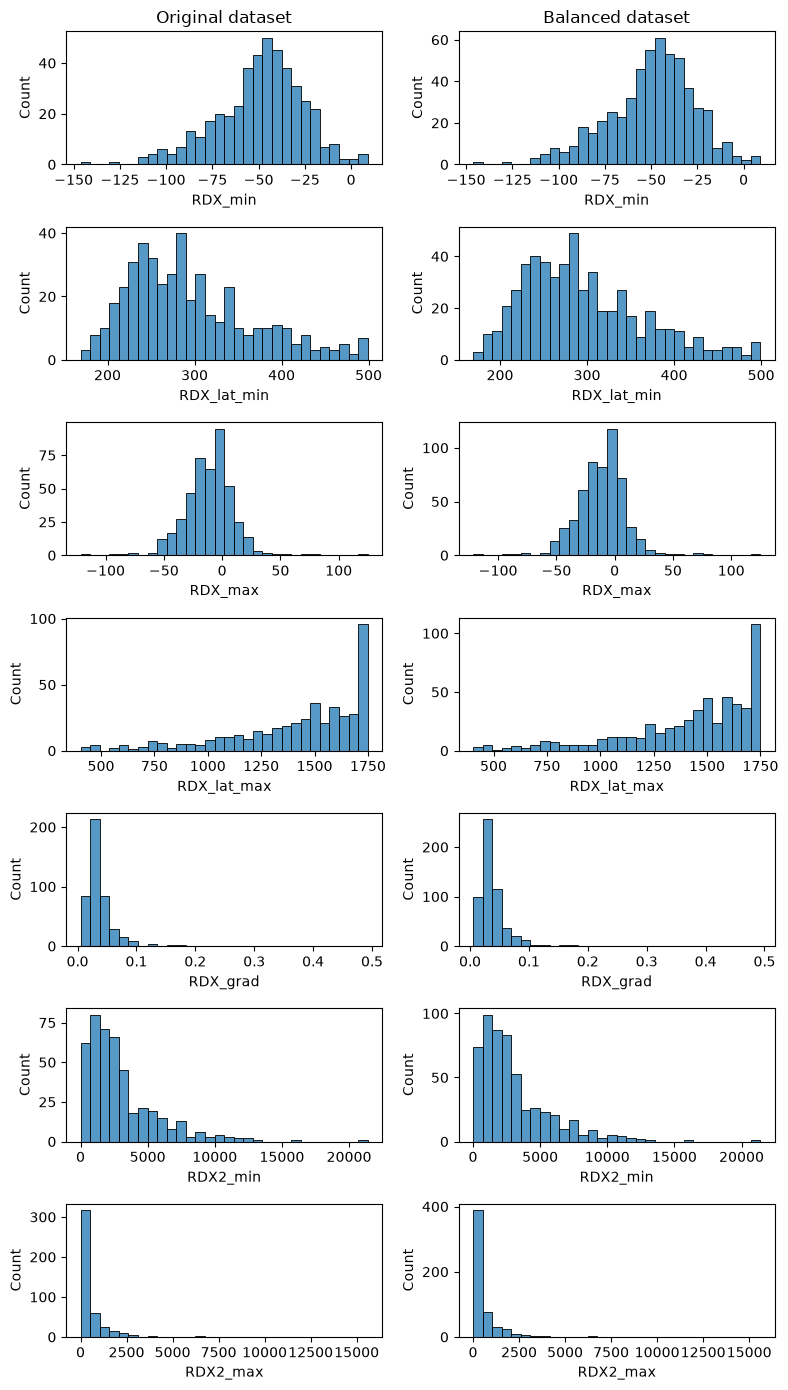

In [ ]:
fig, ax = plt.subplots(7, 2, figsize=(8, 14))

sns.histplot(df, x='RDX_min', bins=30, ax=ax[0][0])
sns.histplot(test, x='RDX_min', bins=30, ax=ax[0][1])

sns.histplot(df, x='RDX_lat_min', bins=30, ax=ax[1][0])
sns.histplot(test, x='RDX_lat_min', bins=30, ax=ax[1][1])

sns.histplot(df, x='RDX_max', bins=30, ax=ax[2][0])
sns.histplot(test, x='RDX_max', bins=30, ax=ax[2][1])

sns.histplot(df, x='RDX_lat_max', bins=30, ax=ax[3][0])
sns.histplot(test, x='RDX_lat_max', bins=30, ax=ax[3][1])

sns.histplot(df, x='RDX_grad', bins=30, ax=ax[4][0])
sns.histplot(test, x='RDX_grad', bins=30, ax=ax[4][1])

sns.histplot(df, x='RDX2_min', bins=30, ax=ax[5][0])
sns.histplot(test, x='RDX2_min', bins=30, ax=ax[5][1])

sns.histplot(df, x='RDX2_max', bins=30, ax=ax[6][0])
sns.histplot(test, x='RDX2_max', bins=30, ax=ax[6][1])

ax[0][0].set_title('Original dataset')
ax[0][1].set_title('Balanced dataset')

# plt.savefig('figures/balanced_whole_dataset_hist', dpi=150)

plt.tight_layout()

In [48]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2)

for train_idx, test_idx in gss.split(X, groups=id):
    trainX = X.iloc[train_idx]
    trainy = y.iloc[train_idx]

    testX = X.iloc[test_idx]
    testy = y.iloc[test_idx]

In [71]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(X, y, groups=id))

trainX = X.iloc[train_idx]
trainy = y.iloc[train_idx]

testX = X.iloc[test_idx]
testy = y.iloc[test_idx]

X_resampled, y_resampled = SMOTE().fit_resample(trainX, trainy)

### Dummy model

In [15]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='uniform', random_state=42)
dummy_clf.fit(X, y)
proba = dummy_clf.predict_proba(X)
score = dummy_clf.score(X, y)

score

0.25225225225225223

### Reference model

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, groups=id):
    trainX_lr = X.iloc[train_idx]
    trainy_lr = y.iloc[train_idx]

    testX_lr = X.iloc[test_idx]
    testy_lr = y.iloc[test_idx]

    
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(trainX_lr, trainy_lr)
score = lr_clf.score(testX_lr, testy_lr)
proba = lr_clf.predict_proba(testX_lr)

score

/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.24444444444444444

### Train, test, split

In [9]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score


## Scaling
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), 
    ('clf', SVC(random_state=42))
])

# pipeline = Pipeline(
#     [
#         ("preprocessor", preprocessor),
#         ('clf', SVC(random_state=42))
# ])

param_grid = [
    {
        'clf' : [SVC(random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
        'clf__kernel': ['linear', 'rbf']
    },
    {
        'clf' : [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [1, 10, 50, 100],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': [5, 20, 50, 100],
        'clf__min_samples_split': [2, 5, 8, 10]
    },
    {
        'clf' : [LogisticRegression(random_state=42)],
        'clf__C': [0.5, 1.0, 1.5, np.inf],
        'clf__l1_ratio': [0, 0.5, 1],
        'clf__solver': ['lbfgs', 'newton-cholesky', 'sag', 'saga'],
        'clf__max_iter': [500, 1000]
    },
    {
        'clf' : [GradientBoostingClassifier(random_state=42)],
        'clf__loss': ['log_loss'],
        'clf__learning_rate': [0.01, 0.1, 1],
        'clf__n_estimators': [1, 100, 1000],
        'clf__min_samples_split': [2, 4, 6],
        'clf__max_depth': [1, 3, 5]
    },
    {
        'clf' : [KNeighborsClassifier()],
        'clf__n_neighbors': [3, 5, 7, 10],
        'clf__weights': ['uniform', 'distance'],
        'clf__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'clf__p': [1, 2]
    },
    {
        'clf' : [AdaBoostClassifier(random_state=42)],
        'clf__n_estimators': [20, 50, 100],
        'clf__learning_rate': [0.01, 0.1, 1]
    }
]

## Store variables
results = {
    'accuracy': [],
    'proba': [],
    'f1_score': [],
    'balanced_accuracy': [],
    'best_params': [],
    'best_model': [],
    'train_cond_distribution': [],
    'test_cond_distribution': [],
    'confusion_matrices': [],
    'train_idx_folds': [],
    'X_train_folds': [],
    'y_train_folds': []
}

## Optimise model using GridSearchCV
outer_cv = StratifiedGroupKFold(n_splits=5)
inner_cv = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in outer_cv.split(X, y, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]

    gridsearch = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=inner_cv, n_jobs=-1)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    y_pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)

    score = best_model.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results['accuracy'].append(score)
    results['proba'].append(proba)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))

    results['best_params'].append(best_params)
    results['best_model'].append(best_model)
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

### Confusion matrices

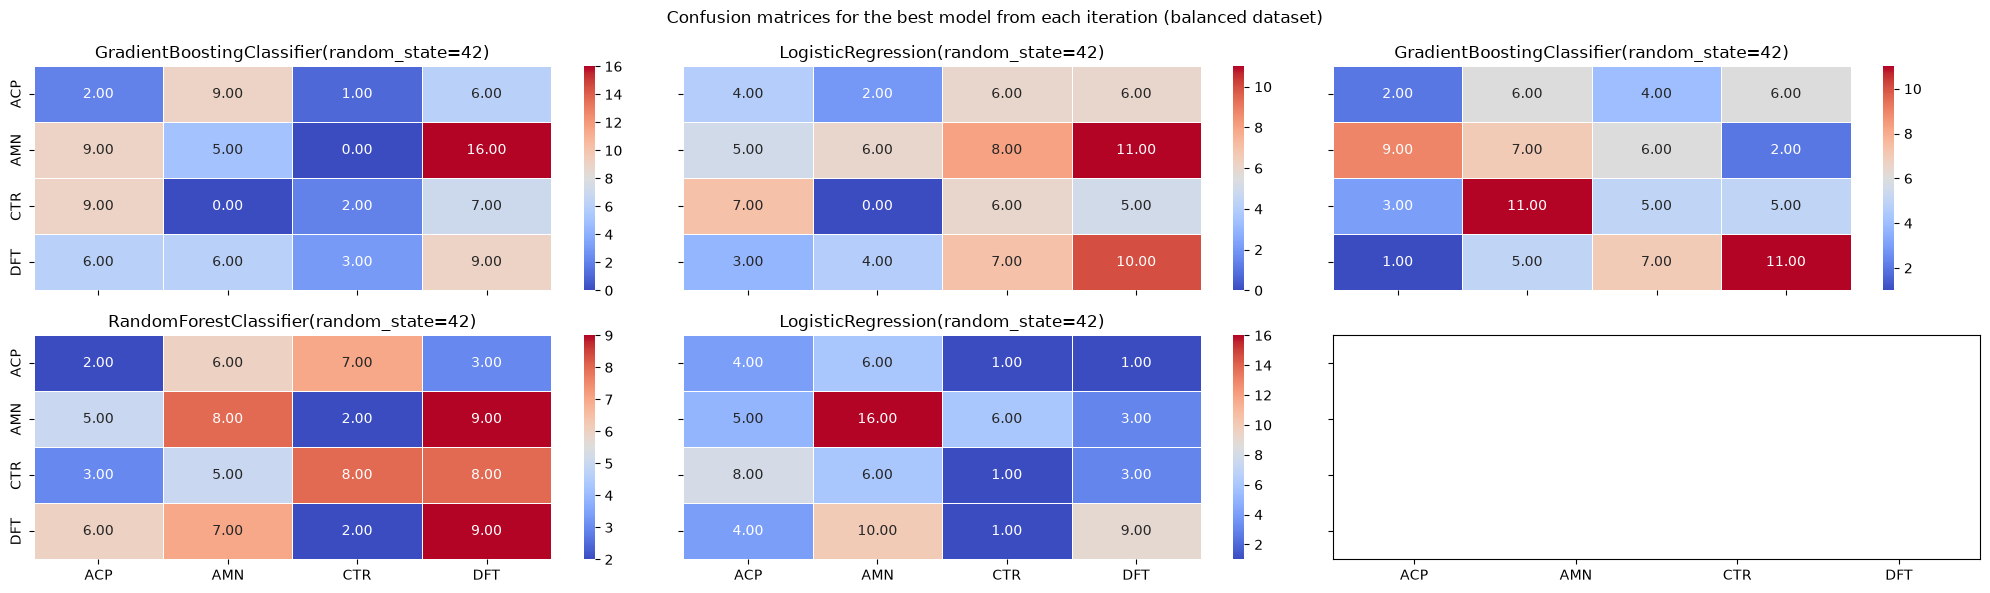

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(20, 6), sharex=True, sharey=True)
ax=ax.flatten()
labels = ['ACP', 'AMN', 'CTR', 'DFT']

for i, cm in enumerate(results['confusion_matrices']):
    cm = pd.DataFrame(cm, index = labels, columns=labels)
    sns.heatmap(cm, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax[i])
    ax[i].set_title(str(results['best_params'][i]['clf']))


fig.suptitle('Confusion matrices for the best model from each iteration (balanced dataset)')
plt.savefig('figures/cm_balanced', dpi=150)
plt.tight_layout()

### Learning curves

0


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

1
2


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/arthur/git/2026_M1_

3
4


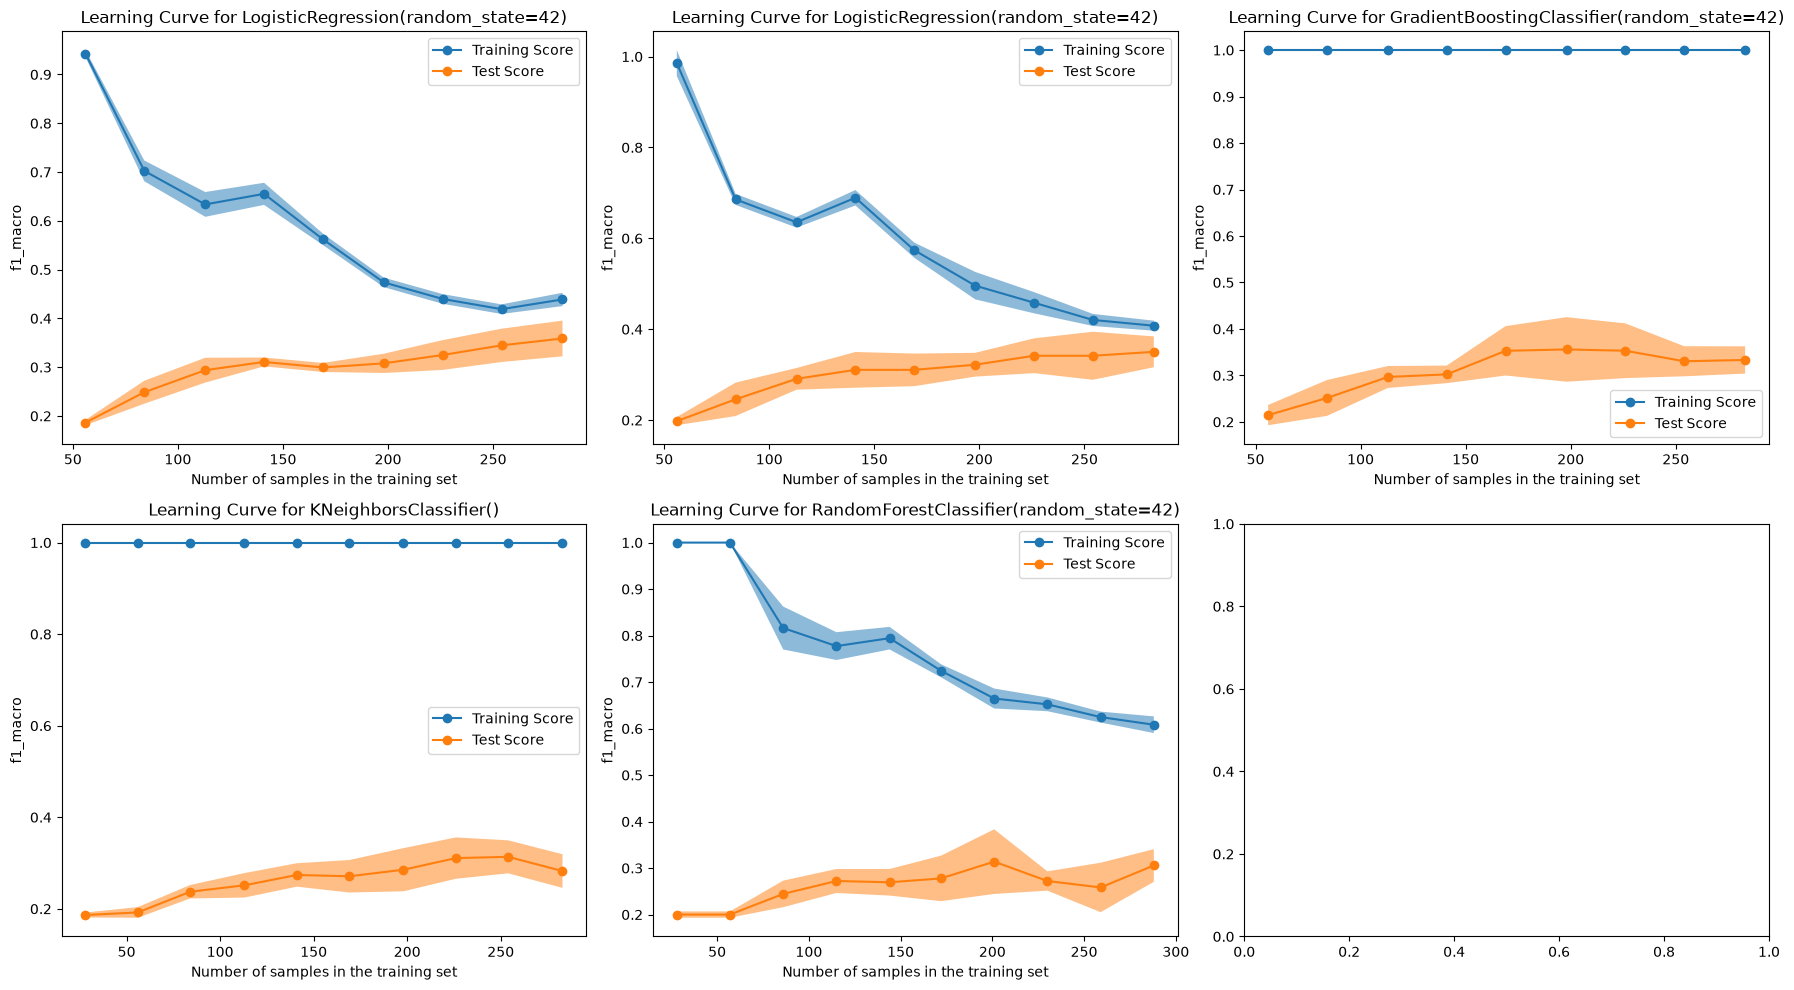

In [ ]:
from sklearn.model_selection import learning_curve, StratifiedKFold, LearningCurveDisplay

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.flatten()

train_sizes = np.linspace(0.1, 1.0, 10)
cv_for_learning = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ax_idx, fold_idx in enumerate(results['best_model']):
    print(ax_idx)
    X_train = results['X_train_folds'][ax_idx]
    y_train = results['y_train_folds'][ax_idx]
    estimator = results['best_model'][ax_idx]

    common_params = {
        "X": X_train,
        "y": y_train,
        "train_sizes": train_sizes,
        "cv": cv_for_learning,
        "score_type": "both",
        "n_jobs": -1,
        "line_kw": {"marker": "o"},
        "std_display_style": "fill_between",
        "score_name": "f1_macro",
    }

    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax[ax_idx])
    handles, label = ax[ax_idx].get_legend_handles_labels()
    ax[ax_idx].legend(handles[:2], ["Training Score", "Test Score"])
    ax[ax_idx].set_title(f"Learning Curve for {results['best_params'][ax_idx]['clf']}")


plt.tight_layout()
# plt.savefig('figures/learning_curve_unbalanced.png', dpi=150)

### Optuna test

In [ ]:
import optuna

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['SVC', 'RandomForest'])
    if classifier_name == 'SVC':
        svc_c = trial.suggest_float('svc_c', 1e-10, 1e10, log=True)
        classifier_obj = SVC(C=svc_c, gamma='auto')
    else:
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=True)
        classifier_obj = RandomForestClassifier(max_depth=rf_max_depth, n_estimators=10)

    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f'BEST: {study.best_params}')





# svm = SVC()

# p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1], "kernel": {'linear', 'poly', 'rbf'}}

# outer_cv = GroupKFold(n_splits=3)
# inner_cv = GroupKFold(n_splits=5)

# scores = []

# for train_idx, test_idx in outer_cv.split(X, y, groups=id):
#     X_train_outer, X_test_outer = X[train_idx], X[test_idx]
#     y_train_outer, y_test_outer = y[train_idx], y[test_idx]

#     clf = GridSearchCV(estimator=svm, param_grid=p_grid, cv=inner_cv)
#     clf.fit(X_train_outer, X_train_outer)
#     scores.append(clf.best_score_)



[I 2026-09-03 19:21:54,100] A new study created in memory with name: no-name-ba5438a9-583c-4301-a983-243161536d01
[I 2026-09-03 19:21:54,102] Trial 0 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,102] Trial 1 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 2}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,103] Trial 2 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.2253276580020046e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 3 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 8}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 4 finished with value: 0.28888888888888886 and parameters: {'classifie

BEST: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}


#### TEST
- transformer: preprocessing
- estimator: model

##### Breakdown
- Step 1: test different base models (SVM, RandomForest, LogisticRegression, XGboost) -> use a DummyClassifier as reference to chance
- Step 2: choose the best model and optimise it

Figure out a clear modelling pipeline